# 가중치 초기화

학습 시작 시점의 가중치가 
- 모두 똑같거나
- 너무 크거나
- 너무 작으면
학습 과정이 비효율적이거나 불안정해질 수 있다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
torch.manual_seed(42)

## 1. 모든 가중치를 0으로 초기화 하는 경우

은닉층의 여러 뉴런이 모두 같은 값으로 시작하면, 학습 중에도 같은 방식으로 업데이트 될 가능성이 크다.
서로 다른 뉴런이 서로 다른 역할을 배우지 못해서 다층 신경망의 의미가 줄어든다.

=> `대칭성 문제(symmerty problem)` 이라고 한다.

In [2]:
# 같은 입력에 대해, 0으로 초기화 된 두 뉴런이 같은 출력을 만드는 예시
X = torch.tensor([
    [1.0, 2.0],
    [2.0, 3.0],
    [3.0, 4.0]
    ])

W = torch.zeros((2, 2))
b = torch.zeros(2)

Z = X @ W + b
print(Z)

tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])


In [3]:
# 0 초기화 vs random 초기화
W_zero = torch.zeros((2, 3))
b_zero = torch.zeros(3)

W_rand = torch.rand((2, 3)) * 0.1
b_rand = torch.zeros(3)

Z_zero = X @ W_zero + b_zero
Z_rand = X @ W_rand + b_rand

print(Z_zero)
print(Z_rand)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
tensor([[0.2801, 0.1696, 0.1585],
        [0.4642, 0.3001, 0.2568],
        [0.6484, 0.4307, 0.3552]])


## 2. 너무 크거나 작은 값으로 초기화하는 경우

1. 너무 큰 초기값
    - 층이 지날수록 값이 지나치게 커질 수 있다.
    - sigmoid나 tanh 같은 함수에서는 출력이 양 끝으로 몰려 기울기가 매우 작아질 수 있다.
2. 너무 작은 초기값
    - 층을 지날수록 값이 지나치게 작아질 수 있다.
    - 신호가 약해져 학습이 느려질 수 있다.

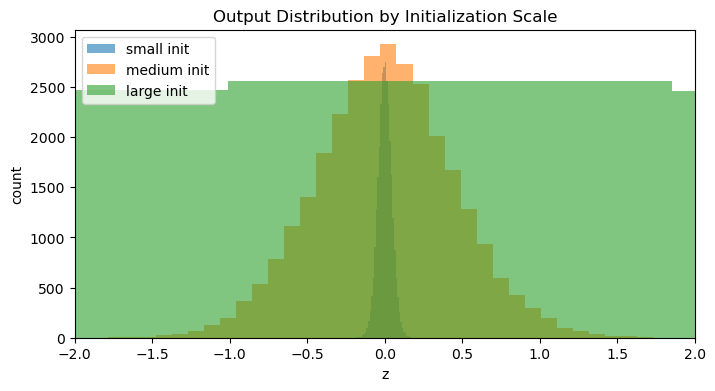

In [5]:
# 같은 입력을 두고 초기 가중치 크기에 따라 출력 분포가 어떻게 달라지는지 확인
X_large = torch.randn(1000, 20)

W_small = torch.randn(20, 30) * 0.01
W_medium = torch.randn(20, 30) * 0.1
W_large = torch.randn(20, 30) * 3.0

Z_small = X_large @ W_small
Z_medium = X_large @ W_medium
Z_large = X_large @ W_large

plt.figure(figsize=(8, 4))
plt.hist(Z_small.numpy().flatten(), bins=40, alpha=0.6, label='small init')
plt.hist(Z_medium.numpy().flatten(), bins=40, alpha=0.6, label='medium init')
plt.hist(Z_large.numpy().flatten(), bins=40, alpha=0.6, label='large init')

plt.title('Output Distribution by Initialization Scale')
plt.xlabel('z')
plt.ylabel('count')
plt.legend()
plt.xlim(-2, 2)
plt.show()


## 3. sigmoid에서 큰 초기값이 불리할 수 있는 이유
- sigmoid 함수는 입력값이 너무 크거나 너무 작으면 출력이 0 또는 1 근처에 몰린다.
- 이 구간에는 도함수 값이 작아진다. 즉 역전파 때 기울기가 작아져 학습이 느려질 수 있다.

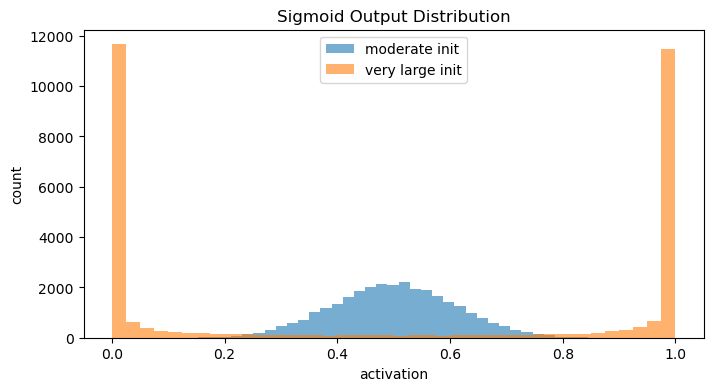

In [6]:
X_sig = torch.randn(1000, 20)

W1 = torch.randn(20, 30) * 0.1
W2 = torch.randn(20, 30) * 3.0

A1 = torch.sigmoid(X_sig @ W1)
A2 = torch.sigmoid(X_sig @ W2)

plt.figure(figsize=(8, 4))
plt.hist(A1.numpy().flatten(), bins=40, alpha=0.6, label='moderate init')
plt.hist(A2.numpy().flatten(), bins=40, alpha=0.6, label='very large init')

plt.title('Sigmoid Output Distribution')
plt.xlabel('activation')
plt.ylabel('count')
plt.legend()
plt.show()

## 4. Xavier 초기화와 He 초기화
입력 노드/출력 노드 수와 활성화 함수 특성을 고려한 초기화 방법을 사용할 수 있다.

1. Xavier 초기화
    - sigmoid, tanh 계열과 함께 자주 언급 된다.
    - 층을 지나며 값이 분산이 너무 커지거나 작아지지 않도록 돕는 아이디어이다.
2. He 초기화
    - ReLU 계열과 함께 자주 언급 된다.
    - ReLU 특성을 고려해 Xavier 보다 조금 더 크게 시작하는 경우가 많다.

In [7]:
linear_xavier = nn.Linear(20, 30)
nn.init.xavier_uniform_(linear_xavier.weight)
nn.init.zeros_(linear_xavier.bias)

linear_he = nn.Linear(20, 30)
nn.init.kaiming_uniform_(linear_he.weight, nonlinearity='relu')
nn.init.zeros_(linear_he.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.], requires_grad=True)

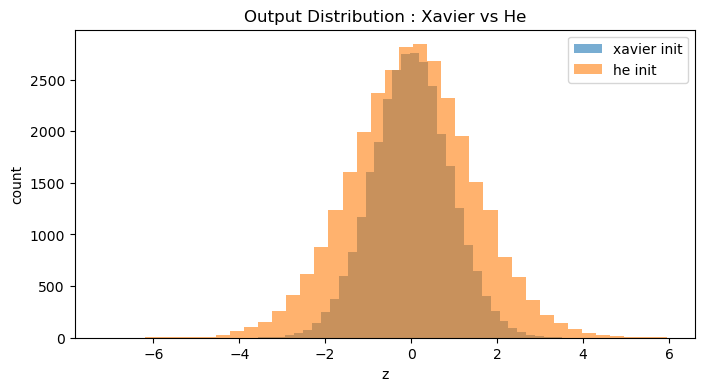

In [8]:
X_compare = torch.randn(1000, 20)

Z_xavier = linear_xavier(X_compare).detach()
Z_he = linear_he(X_compare).detach()

plt.figure(figsize=(8, 4))
plt.hist(Z_xavier.numpy().flatten(), bins=40, alpha=0.6, label='xavier init')
plt.hist(Z_he.numpy().flatten(), bins=40, alpha=0.6, label='he init')

plt.title('Output Distribution : Xavier vs He')
plt.xlabel('z')
plt.ylabel('count')
plt.legend()
plt.show()

## 5. 학습 비교

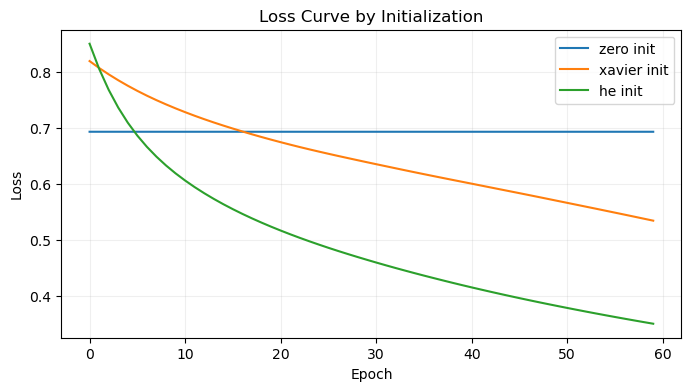

In [9]:
# 이진분류용 toy 데이터
torch.manual_seed(42)

X = torch.randn(300, 20)
true_w = torch.randn(20, 1)
logits = X @ true_w + 0.3
y = (logits > 0).float()

class InitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(20, 16)    # fully connected layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)

def initialize_model(model, mode='xavier'):
    if mode == 'zero':
        for name, param in model.named_parameters():
            if 'weight' in name:
                nn.init.zeros_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

    elif mode == 'xavier':
        for name, param in model.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

    elif mode == 'he':
        for name, param in model.named_parameters():
            if 'weight' in name:
                nn.init.kaiming_uniform_(param, nonlinearity='relu')
            elif 'bias' in name:
                nn.init.zeros_(param)

def train_once(init_mode, epochs=60):
    model = InitNet()
    initialize_model(model, init_mode)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    loss_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

    return loss_history

zero_history = train_once('zero')
xavier_history = train_once('xavier')
he_history = train_once('he')

plt.figure(figsize=(8, 4))
plt.plot(zero_history, label='zero init')
plt.plot(xavier_history, label='xavier init')
plt.plot(he_history, label='he init')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve by Initialization')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 초기화 값 확인
실무에서는 모든 초기화를 직접 짜지 않는 경우도 많다.
예를 들어 PyTorch의 `nn.Linear` 등은 기본 초기화를 가지고 시작한다.

In [11]:
model = InitNet()

print(model.fc1.weight)
print(model.fc1.bias.mean().item())
print(model.fc2.weight.mean().item())
print(model.fc2.bias.mean().item())

Parameter containing:
tensor([[-0.0978,  0.1949,  0.1527,  0.1858,  0.1937,  0.0513,  0.1229, -0.1197,
          0.0376,  0.2144, -0.0771,  0.0527, -0.1142,  0.0827,  0.0728,  0.1688,
          0.0012,  0.1068,  0.1356,  0.0360],
        [-0.2109,  0.1585, -0.1432,  0.1036, -0.1673,  0.0651, -0.0418, -0.2002,
          0.1021, -0.0520, -0.0930, -0.0695,  0.1520,  0.1314,  0.0609,  0.0936,
          0.1149,  0.0925,  0.1904,  0.1346],
        [-0.1151, -0.0341,  0.1043,  0.1779, -0.1858, -0.1109, -0.1109,  0.2112,
          0.2195, -0.0999, -0.0691,  0.0040,  0.0131, -0.0637, -0.1631, -0.1190,
         -0.0187,  0.0242,  0.0086, -0.2053],
        [ 0.1980, -0.1302, -0.0548,  0.2074,  0.0015, -0.1787,  0.1288, -0.0841,
          0.2168, -0.0649, -0.1671, -0.1663,  0.0012, -0.0360,  0.1741,  0.0134,
         -0.1344,  0.0250, -0.1654,  0.0334],
        [ 0.0591, -0.2108, -0.1530, -0.1123, -0.0782, -0.0406,  0.0938, -0.1765,
          0.1156, -0.1550,  0.1964, -0.1276, -0.1711,  0.1603,  0